# Convolutional Latent Free-Energy Score Model on MNIST

This notebook implements the model in `notes/conv_latent_free_energy_crossbar.pdf`:

\[
F_\theta(x,t)=\frac{\lVert x\rVert^2}{2\sigma_t^2}
- b^\top x
- \sum_{u,k}\operatorname{softplus}(a_k+\langle w_k,P_u x\rangle),
\]

with the conservative score

\[
s_\theta(x,t)= -\nabla_x F_\theta(x,t)
=-\frac{x}{\sigma_t^2}+b+W^\dagger * \sigma(W*x+a).
\]

The hidden units are fast Bernoulli feature detectors indexed by spatial location `u`
and channel `k`. The encoder and decoder weights are tied, so the score is the
gradient of an explicit scalar free energy rather than an arbitrary CNN vector field.

The training objective is denoising force matching. For OU corruption

\[
x_t=\alpha_t x_0+\sigma_t\epsilon,\qquad \alpha_t=e^{-t},
\]

the target score is

\[
s^\star(x_t,x_0,t)=\frac{\alpha_t x_0-x_t}{\sigma_t^2}.
\]

The notebook does four things:

1. loads and downsamples MNIST images;
2. checks that the analytic tied convolutional score equals `jax.grad` of the free energy;
3. checks the local crossbar gradient formula against autodiff;
4. runs a small GPU hyperparameter search, then retrains the best quick configuration.

The quick defaults are intentionally modest so the whole notebook executes on a single GPU.
Set `RESEARCH_MODE = True` for a wider sweep and longer training.

In [1]:
import math
import time
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, random
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())
print("Default backend:", jax.default_backend())

JAX version: 0.4.33
Devices: [CudaDevice(id=0)]
Default backend: gpu


## Configuration

The defaults below are a proof-of-concept run:

- `12 x 12` MNIST keeps the visible dimension small enough for repeated sweeps.
- The quick proof-of-concept uses MNIST 0/1, matching the small-image experiment
  suggested in the latent-DAM notes. To stress-test reusable strokes across all digits,
  change DIGITS to all ten classes and use RESEARCH_MODE = True.
- The hyperparameter search sweeps hidden channels, kernel size, initialization scale,
  and learning rate.

For closer-to-paper experiments, increase `N_TRAIN`, `N_TIME_FINAL`,
`STEPS_PER_TIME_FINAL`, and `N_REVERSE_STEPS`.

In [2]:
SEED = 0
RESEARCH_MODE = False

IMG_SIDE = 12
IMG_CHANNELS = 1
DIGITS = (0, 1)

if RESEARCH_MODE:
    N_TRAIN = 8192
    N_VALID = 2048
    N_TIME_SWEEP = 8
    STEPS_PER_TIME_SWEEP = 220
    N_TIME_FINAL = 12
    STEPS_PER_TIME_FINAL = 360
    BATCH_SIZE = 192
    N_REVERSE_STEPS = 260
    N_SAMPLES = 96
    SWEEP_CONFIGS = [
        {"hidden_ch": 8, "kernel": 3, "W_scale": 0.08, "lr": 3e-3},
        {"hidden_ch": 16, "kernel": 3, "W_scale": 0.08, "lr": 3e-3},
        {"hidden_ch": 24, "kernel": 3, "W_scale": 0.08, "lr": 2e-3},
        {"hidden_ch": 16, "kernel": 5, "W_scale": 0.06, "lr": 2e-3},
        {"hidden_ch": 24, "kernel": 5, "W_scale": 0.06, "lr": 2e-3},
        {"hidden_ch": 32, "kernel": 3, "W_scale": 0.05, "lr": 1e-3},
    ]
else:
    N_TRAIN = 1600
    N_VALID = 512
    N_TIME_SWEEP = 8
    STEPS_PER_TIME_SWEEP = 250
    N_TIME_FINAL = 12
    STEPS_PER_TIME_FINAL = 1500
    BATCH_SIZE = 128
    N_REVERSE_STEPS = 300
    N_SAMPLES = 64
    SWEEP_CONFIGS = [
        {"hidden_ch": 8, "kernel": 3, "W_scale": 0.06, "lr": 3e-3},
        {"hidden_ch": 16, "kernel": 3, "W_scale": 0.05, "lr": 3e-3},
        {"hidden_ch": 16, "kernel": 5, "W_scale": 0.04, "lr": 2e-3},
        {"hidden_ch": 24, "kernel": 3, "W_scale": 0.04, "lr": 2e-3},
        {"hidden_ch": 32, "kernel": 3, "W_scale": 0.035, "lr": 15e-4},
        {"hidden_ch": 32, "kernel": 5, "W_scale": 0.035, "lr": 1e-3},
        {"hidden_ch": 32, "kernel": 7, "W_scale": 0.030, "lr": 8e-4},
        {"hidden_ch": 48, "kernel": 5, "W_scale": 0.030, "lr": 8e-4},
        {"hidden_ch": 64, "kernel": 5, "W_scale": 0.025, "lr": 6e-4},
    ]

kBT = 1.0
TAU = 3.0
T_MIN = 8e-2
TIME_GRID_SWEEP = jnp.linspace(T_MIN, TAU, N_TIME_SWEEP)
TIME_GRID_FINAL = jnp.linspace(T_MIN, TAU, N_TIME_FINAL)

GRAD_CLIP = 10.0
REG_SCALE = 1e-6
VISIBLE_BIAS_SCALE = 0.0
HIDDEN_BIAS_SCALE = -1.25

key = random.PRNGKey(SEED)
print(f"config: {IMG_SIDE}x{IMG_SIDE} MNIST, digits={DIGITS}")
print(f"quick sweep configs: {SWEEP_CONFIGS}")

config: 12x12 MNIST, digits=(0, 1)
quick sweep configs: [{'hidden_ch': 8, 'kernel': 3, 'W_scale': 0.06, 'lr': 0.003}, {'hidden_ch': 16, 'kernel': 3, 'W_scale': 0.05, 'lr': 0.003}, {'hidden_ch': 16, 'kernel': 5, 'W_scale': 0.04, 'lr': 0.002}, {'hidden_ch': 24, 'kernel': 3, 'W_scale': 0.04, 'lr': 0.002}, {'hidden_ch': 32, 'kernel': 3, 'W_scale': 0.035, 'lr': 0.0015}, {'hidden_ch': 32, 'kernel': 5, 'W_scale': 0.035, 'lr': 0.001}, {'hidden_ch': 32, 'kernel': 7, 'W_scale': 0.03, 'lr': 0.0008}, {'hidden_ch': 48, 'kernel': 5, 'W_scale': 0.03, 'lr': 0.0008}, {'hidden_ch': 64, 'kernel': 5, 'W_scale': 0.025, 'lr': 0.0006}]


2026-05-22 01:31:44.613432: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Minimal PyTree Adam

This is the same small optimizer pattern used in the existing notebooks. Keeping it
inline makes the notebook portable and avoids adding a dependency on Optax for this
single experiment.

In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {
        "m": tree_zeros_like(params),
        "v": tree_zeros_like(params),
        "t": jnp.array(0, dtype=jnp.int32),
    }


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(
        lambda m, g: beta1 * m + (1.0 - beta1) * g, state["m"], grads
    )
    v = jax.tree_util.tree_map(
        lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g), state["v"], grads
    )
    m_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params,
        m_hat,
        v_hat,
    )
    return params, {"m": m, "v": v, "t": t}

## Data: MNIST as clamped visible oscillator states

Pixels are mapped from `[0, 1]` to `[-1, 1]`. With `kBT = 1`, this puts
the clean image scale near the high-noise Gaussian prior used by the reverse OU sampler.

The downsampler uses central crop plus average pooling. `IMG_SIDE = 12` crops MNIST
to `24 x 24` and pools by `2`, matching the small-image setup used in the project notes.

2026-05-22 01:31:44.862896: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779413504.873912   15705 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779413504.877431   15705 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


train_images: (1600, 12, 12, 1) float32
valid_images: (512, 12, 12, 1) float32
train mean/std: -0.6710148453712463 0.6199228763580322
train class counts: {0: 751, 1: 849}


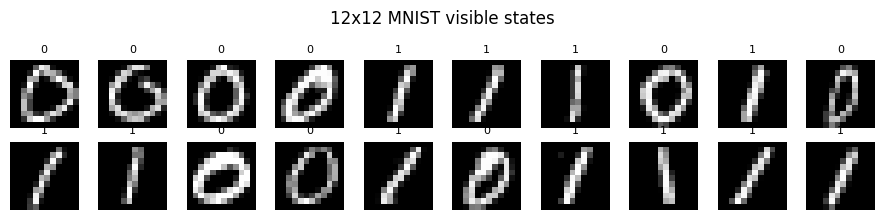

In [4]:
def _load_mnist_raw():
    from tensorflow.keras.datasets import mnist

    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    return (
        np.asarray(x_train, dtype=np.uint8),
        np.asarray(y_train, dtype=np.int32),
        np.asarray(x_test, dtype=np.uint8),
        np.asarray(y_test, dtype=np.int32),
    )


def downsample_avg(x_28, out_side):
    if out_side < 1 or out_side > 28:
        raise ValueError(f"out_side must be in [1, 28], got {out_side}")
    k = 28 // out_side
    cropped_side = out_side * k
    pad = (28 - cropped_side) // 2
    x = x_28[:, pad : pad + cropped_side, pad : pad + cropped_side].astype(np.float32) / 255.0
    if k > 1:
        x = x.reshape(-1, out_side, k, out_side, k).mean(axis=(2, 4))
    return x


def prep_mnist_split(x_raw, y_raw, digits, n, out_side, seed):
    mask = np.isin(y_raw, np.asarray(digits))
    x = x_raw[mask]
    y = y_raw[mask]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(x.shape[0])[:n]
    x = downsample_avg(x[idx], out_side)
    x = 2.0 * x - 1.0
    x = x[..., None]
    return jnp.asarray(x), jnp.asarray(y[idx])


x_train_raw, y_train_raw, x_test_raw, y_test_raw = _load_mnist_raw()
train_images, train_labels = prep_mnist_split(
    x_train_raw, y_train_raw, DIGITS, N_TRAIN, IMG_SIDE, SEED
)
valid_images, valid_labels = prep_mnist_split(
    x_test_raw, y_test_raw, DIGITS, N_VALID, IMG_SIDE, SEED + 1
)

print("train_images:", train_images.shape, train_images.dtype)
print("valid_images:", valid_images.shape, valid_images.dtype)
print("train mean/std:", float(jnp.mean(train_images)), float(jnp.std(train_images)))
print("train class counts:", {int(d): int(jnp.sum(train_labels == d)) for d in DIGITS})

fig, axes = plt.subplots(2, 10, figsize=(9.0, 2.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(np.asarray(train_images[i, :, :, 0]), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(int(train_labels[i]), fontsize=8)
    ax.axis("off")
plt.suptitle(f"{IMG_SIDE}x{IMG_SIDE} MNIST visible states")
plt.tight_layout()
plt.show()

## OU corruption and denoising target

The forward process is

\[
x_t = \alpha_t x_0 + \sigma_t\epsilon,\qquad
\alpha_t=e^{-t},\qquad \sigma_t^2=k_BT(1-\alpha_t^2).
\]

Because `x0` and the injected noise are known during training, the target score is
available locally as a clamped force-error signal:

\[
s^\star = -\frac{x_t-\alpha_t x_0}{\sigma_t^2}.
\]

In [5]:
def ou_coeffs(t, kBT_val=1.0):
    a = jnp.exp(-t)
    sigma2 = kBT_val * (1.0 - a * a)
    return a, jnp.maximum(sigma2, 1e-6)


def corrupt_ou(key, x0, t, kBT_val=1.0):
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT_val)
    xt = a * x0 + jnp.sqrt(sigma2) * eps
    target = -kBT_val * (xt - a * x0) / sigma2
    return xt, target

## Convolutional latent free-energy model

The implementation uses `NHWC` images and `HWIO` filters:

- `conv_encoder(x, W)` computes \(W*x\);
- `hidden_mean = sigmoid(W*x + a)` computes the fast Bernoulli posterior mean;
- `conv_transpose_tied(hidden_mean, W)` computes \(W^\dagger*q\).

The same filter tensor appears in the encoder and decoder. This tied condition is what
makes the model a free-energy score model rather than a generic encoder-decoder CNN.

In [6]:
def conv_encoder(x, W):
    return lax.conv_general_dilated(
        x,
        W,
        window_strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )


def conv_transpose_tied(q, W):
    return lax.conv_transpose(
        q,
        W,
        strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
        transpose_kernel=True,
    )


def init_conv_free_energy(key, hidden_ch, kernel, W_scale, image_shape):
    kW, ka, kb = random.split(key, 3)
    H, W_img, C = image_shape
    params = {
        "W": W_scale * random.normal(kW, (kernel, kernel, C, hidden_ch)),
        "a": HIDDEN_BIAS_SCALE + 0.01 * random.normal(ka, (hidden_ch,)),
        "b": VISIBLE_BIAS_SCALE + jnp.zeros((1, H, W_img, C)),
    }
    return params


def conv_hidden(params, x):
    z = conv_encoder(x, params["W"]) + params["a"][None, None, None, :]
    q = jax.nn.sigmoid(z)
    return z, q


def conv_score(params, x, sigma2):
    _, q = conv_hidden(params, x)
    return -x / sigma2 + params["b"] + conv_transpose_tied(q, params["W"])


def conv_log_unnormalized(params, x, sigma2):
    z, _ = conv_hidden(params, x)
    quad = -0.5 * jnp.sum(x * x, axis=(1, 2, 3)) / sigma2
    visible = jnp.sum(params["b"] * x, axis=(1, 2, 3))
    hidden = jnp.sum(jax.nn.softplus(z), axis=(1, 2, 3))
    return quad + visible + hidden


def conv_free_energy(params, x, sigma2):
    return -conv_log_unnormalized(params, x, sigma2)

## Test 1: score equals the free-energy gradient

This catches mistakes in convolution transpose conventions. If the tied decoder is wrong,
the score no longer equals \(-\nabla_x F\), and the associative-memory/free-energy
interpretation is broken.

In [7]:
def score_autodiff(params, x_batch, sigma2):
    def logp_single(x_single):
        return conv_log_unnormalized(params, x_single[None, ...], sigma2)[0]

    return jax.vmap(jax.grad(logp_single))(x_batch)


key, k_test = random.split(key)
p_test = init_conv_free_energy(
    k_test, hidden_ch=4, kernel=3, W_scale=0.05, image_shape=train_images.shape[1:]
)
x_test = train_images[:4]
for t_test in [0.05, 0.5, 1.5, TAU]:
    _, s2 = ou_coeffs(jnp.asarray(t_test), kBT)
    analytic = conv_score(p_test, x_test, s2)
    autodiff = score_autodiff(p_test, x_test, s2)
    err = float(jnp.max(jnp.abs(analytic - autodiff)))
    print(f"t={t_test:5.3f} | sigma_t^2={float(s2):.4f} | max score error={err:.3e}")

t=0.050 | sigma_t^2=0.0952 | max score error=9.537e-07
t=0.500 | sigma_t^2=0.6321 | max score error=1.192e-07
t=1.500 | sigma_t^2=0.9502 | max score error=1.192e-07
t=3.000 | sigma_t^2=0.9975 | max score error=1.192e-07


## Local crossbar gradient

For one denoising sample loss

\[
\ell=\frac{1}{2}\lVert s_\theta(x,t)-s^\star\rVert^2,
\qquad \delta=s_\theta-s^\star,
\]

the PDF derives the tied-weight filter gradient

\[
\frac{\partial \ell}{\partial w_k}
=\sum_u
\left[
q_{uk}P_u\delta
+
q_{uk}(1-q_{uk})\eta_{uk}P_u x
\right],
\qquad \eta = W*\delta.
\]

The first term is the decoder/force-synthesis update. The second term is the encoder
susceptibility correction. Both use only clamped local visible values, local force errors,
hidden activities, and one hidden error current.

The code below computes these local gradients explicitly with patch extraction and checks
them against full JAX autodiff.

In [8]:
def extract_patches_same(x, kernel):
    return lax.conv_general_dilated_patches(
        x,
        filter_shape=(kernel, kernel),
        window_strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NHWC", "HWIO", "NHWC"),
    )


def conv_dsm_loss_from_batch(params, xt, target, sigma2):
    pred = conv_score(params, xt, sigma2)
    delta = pred - target
    return 0.5 * jnp.mean(jnp.sum(delta * delta, axis=(1, 2, 3)))


def local_conv_grads_from_batch(params, xt, target, sigma2, reg_scale=0.0):
    W = params["W"]
    kernel = W.shape[0]
    z, q = conv_hidden(params, xt)
    pred = -xt / sigma2 + params["b"] + conv_transpose_tied(q, W)
    delta = pred - target
    loss = 0.5 * jnp.mean(jnp.sum(delta * delta, axis=(1, 2, 3)))

    eta = conv_encoder(delta, W)
    qprime_eta = q * (1.0 - q) * eta

    patches_delta = extract_patches_same(delta, kernel)
    patches_x = extract_patches_same(xt, kernel)
    B = xt.shape[0]

    grad_W_flat = (
        jnp.einsum("bhwk,bhwp->pk", q, patches_delta)
        + jnp.einsum("bhwk,bhwp->pk", qprime_eta, patches_x)
    ) / B
    grad_W = jnp.reshape(grad_W_flat, W.shape)
    grad_a = jnp.mean(jnp.sum(qprime_eta, axis=(1, 2)), axis=0)
    grad_b = jnp.mean(delta, axis=0, keepdims=True)

    grads = {"W": grad_W, "a": grad_a, "b": grad_b}
    if reg_scale:
        loss = loss + reg_scale * tree_sqnorm(params)
        grads = jax.tree_util.tree_map(lambda g, p: g + 2.0 * reg_scale * p, grads, params)
    return loss, grads


key, k_noise = random.split(key)
t_check = jnp.asarray(0.7)
_, s2_check = ou_coeffs(t_check, kBT)
xt_check, target_check = corrupt_ou(k_noise, train_images[:8], t_check, kBT)

loss_local, grads_local = local_conv_grads_from_batch(
    p_test, xt_check, target_check, s2_check, reg_scale=0.0
)
loss_auto, grads_auto = jax.value_and_grad(conv_dsm_loss_from_batch)(
    p_test, xt_check, target_check, s2_check
)

print("loss local/autodiff:", float(loss_local), float(loss_auto))
for name in ["W", "a", "b"]:
    max_err = float(jnp.max(jnp.abs(grads_local[name] - grads_auto[name])))
    rel = float(max_err / (jnp.max(jnp.abs(grads_auto[name])) + 1e-8))
    print(f"grad {name}: max_abs_err={max_err:.3e}, rel={rel:.3e}")

loss local/autodiff: 28.355907440185547 28.355907440185547
grad W: max_abs_err=9.537e-07, rel=6.129e-08
grad a: max_abs_err=5.960e-08, rel=3.780e-08


grad b: max_abs_err=0.000e+00, rel=0.000e+00


## Per-slice training

Training is done independently at each diffusion time, warm-starting from the next
higher-noise slice. This mirrors the physical driving protocol: the device is programmed
for a time slice, clamped to noisy data, locally updated, then moved to a slightly lower
noise level.

The inner loop uses the local gradient formula above rather than differentiating through
the whole score computation. This is the software analogue of the crossbar update rule.

In [9]:
def conv_batch_loss_and_grads(params, key, data, t, batch_size, reg_scale, kBT_val):
    k_idx, k_noise = random.split(key)
    idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
    x0 = data[idx]
    xt, target = corrupt_ou(k_noise, x0, t, kBT_val)
    _, sigma2 = ou_coeffs(t, kBT_val)
    return local_conv_grads_from_batch(params, xt, target, sigma2, reg_scale)


@partial(jax.jit, static_argnames=("batch_size", "steps"))
def _train_slice_scan(params, opt_state, key, data, t, batch_size, steps, lr):
    def body(carry, _):
        params, opt_state, key = carry
        key, sub = random.split(key)
        loss_val, grads = conv_batch_loss_and_grads(
            params, sub, data, t, batch_size, REG_SCALE, kBT
        )
        grads = clip_tree(grads, GRAD_CLIP)
        params, opt_state = adam_step(params, opt_state, grads, lr=lr)
        return (params, opt_state, key), loss_val

    (params, opt_state, key), losses = lax.scan(
        body, (params, opt_state, key), xs=None, length=steps
    )
    return params, opt_state, key, losses


def train_conv_schedule(
    key,
    data,
    config,
    t_grid,
    steps_per_time,
    batch_size,
    verbose=True,
):
    key, k_init = random.split(key)
    params = init_conv_free_energy(
        k_init,
        hidden_ch=config["hidden_ch"],
        kernel=config["kernel"],
        W_scale=config["W_scale"],
        image_shape=data.shape[1:],
    )
    params_by_idx = [None for _ in range(len(t_grid))]
    losses_by_idx = [None for _ in range(len(t_grid))]
    wall0 = time.time()

    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        params, opt_state, key, losses = _train_slice_scan(
            params,
            opt_state,
            key,
            data,
            t,
            batch_size,
            steps_per_time,
            config["lr"],
        )
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(losses))
        if verbose:
            _, s2 = ou_coeffs(t, kBT)
            print(
                f"conv h={config['hidden_ch']:>2}, k={config['kernel']} | "
                f"t={float(t):.3f} sigma2={float(s2):.4f} "
                f"loss={float(losses[-1]):.4e}"
            )

    wall = time.time() - wall0
    if verbose:
        print(f"finished config {config} in {wall:.1f}s")
    return params_by_idx, losses_by_idx, wall, key

## Validation loss and reverse sampling

The validation metric is a denoising-score loss evaluated on held-out MNIST images at
several noise levels. Sampling uses the same reverse OU convention as the existing
notebooks:

\[
dx = [x + 2s_\theta(x,t)]\,dr + \sqrt{2k_BT}\,dw.
\]

This sampler is deliberately simple. The goal here is to test whether the learned local
free-energy field has digit-like basins, not to compete with a modern diffusion U-Net.
After the reverse rollout reaches `T_MIN`, it applies the standard Tweedie denoising
estimate `x0_hat = (x_t + sigma_t^2 * score(x_t, t)) / alpha_t`; otherwise the
displayed images are still samples at a nonzero noise level.

In [10]:
def stack_conv_params(params_seq):
    return {
        "W": jnp.stack([p["W"] for p in params_seq], axis=0),
        "a": jnp.stack([p["a"] for p in params_seq], axis=0),
        "b": jnp.stack([p["b"] for p in params_seq], axis=0),
    }


def params_at(stacked, idx):
    return {"W": stacked["W"][idx], "a": stacked["a"][idx], "b": stacked["b"][idx]}


def build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val):
    dt = tau / n_steps
    ss = jnp.maximum(t_min, tau - jnp.arange(n_steps) * dt)
    _, sigma2_s = ou_coeffs(ss, kBT_val)
    diffs = jnp.abs(ss[:, None] - t_grid[None, :])
    idx = jnp.argmin(diffs, axis=1).astype(jnp.int32)
    return dt, sigma2_s, idx


@partial(jax.jit, static_argnames=("n_samples", "n_steps", "clip_x", "final_denoise", "sampler"))
def reverse_sample_conv(
    key,
    stacked,
    t_grid,
    n_samples,
    n_steps,
    tau=TAU,
    t_min=T_MIN,
    kBT_val=kBT,
    clip_x=2.0,
    final_denoise=True,
    sampler="sde",
):
    key, k_init = random.split(key)
    image_shape = stacked["b"].shape[2:]
    x = jnp.sqrt(kBT_val) * random.normal(k_init, (n_samples,) + image_shape)
    dt, sigma2_s, idx_s = build_reverse_schedule(n_steps, t_grid, tau, t_min, kBT_val)

    def body(carry, step_inputs):
        x, key = carry
        sigma2, idx = step_inputs
        params = params_at(stacked, idx)
        score = conv_score(params, x, sigma2)
        key, k_noise = random.split(key)
        if sampler == "sde":
            x = x + (x + 2.0 * score) * dt + jnp.sqrt(2.0 * kBT_val * dt) * random.normal(
                k_noise, x.shape
            )
        else:
            x = x + (x + score) * dt
        x = jnp.clip(x, -clip_x, clip_x)
        return (x, key), x

    (x_final, key), _ = lax.scan(body, (x, key), (sigma2_s, idx_s))
    if final_denoise:
        a_min, sigma2_min = ou_coeffs(t_min, kBT_val)
        params_min = params_at(stacked, jnp.array(0, dtype=jnp.int32))
        score_min = conv_score(params_min, x_final, sigma2_min)
        x_final = (x_final + sigma2_min * score_min) / jnp.maximum(a_min, 1e-6)
        x_final = jnp.clip(x_final, -1.0, 1.0)
    return x_final, key


@partial(jax.jit, static_argnames=("batch_size",))
def validation_dsm_loss(params_seq_stacked, key, data, t_grid, batch_size):
    time_indices = jnp.arange(t_grid.shape[0], dtype=jnp.int32)

    def one_time(carry, t_idx):
        key = carry
        key, k_idx, k_noise = random.split(key, 3)
        t = t_grid[t_idx]
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT)
        _, sigma2 = ou_coeffs(t, kBT)
        params = params_at(params_seq_stacked, t_idx)
        loss = conv_dsm_loss_from_batch(params, xt, target, sigma2)
        return key, loss

    _, losses = lax.scan(one_time, key, time_indices)
    return jnp.mean(losses)

## Diagnostics

The nearest-neighbour diagnostic asks whether generated samples are close to training
examples. It is not a complete image-quality metric, but it is useful for the specific
DenseAM/free-energy question:

- much smaller sample-to-train distance than train-to-train distance suggests memorization;
- much larger distance suggests off-manifold samples;
- overlap suggests the model is landing in the training manifold without exact copying.

The class histogram assigns each sample the label of its nearest training image.

In [11]:
def flatten_images(x):
    return np.asarray(x).reshape((x.shape[0], -1))


def pairwise_l2(a, b, block=256):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    out = np.empty((a.shape[0], b.shape[0]), dtype=np.float32)
    bn = np.sum(b * b, axis=1)
    for i in range(0, a.shape[0], block):
        ai = a[i : i + block]
        an = np.sum(ai * ai, axis=1, keepdims=True)
        d2 = an + bn[None, :] - 2.0 * ai @ b.T
        out[i : i + block] = np.sqrt(np.maximum(d2, 0.0))
    return out


def sample_diagnostics(samples, train_x, train_y):
    s = flatten_images(samples)
    tr = flatten_images(train_x)
    d_st = pairwise_l2(s, tr)
    nn_idx = d_st.argmin(axis=1)
    d_sample_train = d_st.min(axis=1)
    pred_digits = np.asarray(train_y)[nn_idx]

    control_n = min(768, tr.shape[0])
    tr_control = tr[:control_n]
    d_tt = pairwise_l2(tr_control, tr_control)
    np.fill_diagonal(d_tt, np.inf)
    d_train_train = d_tt.min(axis=1)
    return {
        "d_sample_train": d_sample_train,
        "d_train_train": d_train_train,
        "pred_digits": pred_digits,
        "nearest_train_idx": nn_idx,
    }


def show_image_grid(arr, title, n_show=64, n_cols=8, vmin=-1.0, vmax=1.0):
    arr = np.asarray(arr)
    n = min(n_show, arr.shape[0])
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(0.85 * n_cols, 0.85 * n_rows))
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(arr[i, :, :, 0], cmap="gray", vmin=vmin, vmax=vmax)
        ax.axis("off")
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()


def summarize_diag(diag):
    counts = {int(d): int(np.sum(diag["pred_digits"] == d)) for d in DIGITS}
    return {
        "median_sample_to_train": float(np.median(diag["d_sample_train"])),
        "median_train_to_train": float(np.median(diag["d_train_train"])),
        "digit_counts": counts,
    }

## Hyperparameter search

The sweep is intentionally small in quick mode. It tests the knobs that matter most for
this architecture:

- hidden channels: number of local feature detectors;
- kernel size: receptive-field size of each feature detector;
- initialization scale: placement of sigmoid knees at the start of training;
- learning rate: stability at low noise, where target scores are largest.

Each configuration is trained on the sweep schedule, evaluated with held-out DSM loss,
sampled, and scored by nearest-neighbour diagnostics.

In [12]:
sweep_results = []

for cfg in SWEEP_CONFIGS:
    print("\n=== sweep config ===", cfg)
    key, sub = random.split(key)
    params_seq, losses, wall, key = train_conv_schedule(
        sub,
        train_images,
        cfg,
        TIME_GRID_SWEEP,
        steps_per_time=STEPS_PER_TIME_SWEEP,
        batch_size=BATCH_SIZE,
        verbose=False,
    )
    stacked = stack_conv_params(params_seq)

    key, sub = random.split(key)
    val_loss = validation_dsm_loss(
        stacked, sub, valid_images, TIME_GRID_SWEEP, batch_size=min(128, BATCH_SIZE)
    )

    key, sub = random.split(key)
    samples, key = reverse_sample_conv(
        sub,
        stacked,
        TIME_GRID_SWEEP,
        n_samples=N_SAMPLES,
        n_steps=N_REVERSE_STEPS,
    )
    diag = sample_diagnostics(samples, train_images, train_labels)
    summary = summarize_diag(diag)
    final_loss = float(np.mean([lh[-1] for lh in losses]))

    row = {
        "config": cfg,
        "params_seq": params_seq,
        "losses": losses,
        "samples": samples,
        "diag": diag,
        "wall": wall,
        "val_loss": float(val_loss),
        "final_train_loss": final_loss,
        **summary,
    }
    sweep_results.append(row)
    print(
        f"val_loss={row['val_loss']:.4e} | final_train_loss={final_loss:.4e} | "
        f"median sample->train={row['median_sample_to_train']:.3f} | "
        f"train control={row['median_train_to_train']:.3f} | wall={wall:.1f}s"
    )
    print("nearest-train digit counts:", row["digit_counts"])

best_val = min(r["val_loss"] for r in sweep_results)
eligible = [r for r in sweep_results if r["val_loss"] <= 1.15 * best_val]
best = min(eligible, key=lambda r: r["median_sample_to_train"])
best_config = best["config"]
print("\nlowest held-out DSM loss:", best_val)
print("selected config within 15% of best DSM loss by sample diagnostic:", best_config)


=== sweep config === {'hidden_ch': 8, 'kernel': 3, 'W_scale': 0.06, 'lr': 0.003}


val_loss=2.2065e+01 | final_train_loss=2.3703e+01 | median sample->train=4.814 | train control=2.540 | wall=1.5s
nearest-train digit counts: {0: 6, 1: 58}

=== sweep config === {'hidden_ch': 16, 'kernel': 3, 'W_scale': 0.05, 'lr': 0.003}


val_loss=2.0526e+01 | final_train_loss=2.0127e+01 | median sample->train=5.011 | train control=2.540 | wall=1.4s
nearest-train digit counts: {0: 13, 1: 51}

=== sweep config === {'hidden_ch': 16, 'kernel': 5, 'W_scale': 0.04, 'lr': 0.002}


val_loss=2.1049e+01 | final_train_loss=1.9673e+01 | median sample->train=4.503 | train control=2.540 | wall=1.5s
nearest-train digit counts: {0: 14, 1: 50}

=== sweep config === {'hidden_ch': 24, 'kernel': 3, 'W_scale': 0.04, 'lr': 0.002}


val_loss=2.3023e+01 | final_train_loss=2.3340e+01 | median sample->train=4.689 | train control=2.540 | wall=1.5s
nearest-train digit counts: {0: 11, 1: 53}

=== sweep config === {'hidden_ch': 32, 'kernel': 3, 'W_scale': 0.035, 'lr': 0.0015}


val_loss=2.5353e+01 | final_train_loss=2.2938e+01 | median sample->train=4.369 | train control=2.540 | wall=1.5s
nearest-train digit counts: {0: 7, 1: 57}

=== sweep config === {'hidden_ch': 32, 'kernel': 5, 'W_scale': 0.035, 'lr': 0.001}


val_loss=2.2467e+01 | final_train_loss=2.2594e+01 | median sample->train=4.442 | train control=2.540 | wall=1.6s
nearest-train digit counts: {0: 11, 1: 53}

=== sweep config === {'hidden_ch': 32, 'kernel': 7, 'W_scale': 0.03, 'lr': 0.0008}


val_loss=2.3857e+01 | final_train_loss=2.2334e+01 | median sample->train=4.192 | train control=2.540 | wall=1.9s
nearest-train digit counts: {0: 10, 1: 54}

=== sweep config === {'hidden_ch': 48, 'kernel': 5, 'W_scale': 0.03, 'lr': 0.0008}


val_loss=2.3802e+01 | final_train_loss=2.3863e+01 | median sample->train=4.757 | train control=2.540 | wall=1.7s
nearest-train digit counts: {0: 16, 1: 48}

=== sweep config === {'hidden_ch': 64, 'kernel': 5, 'W_scale': 0.025, 'lr': 0.0006}


val_loss=2.5271e+01 | final_train_loss=2.3950e+01 | median sample->train=5.363 | train control=2.540 | wall=1.8s
nearest-train digit counts: {0: 17, 1: 47}

lowest held-out DSM loss: 20.5256404876709
selected config within 15% of best DSM loss by sample diagnostic: {'hidden_ch': 32, 'kernel': 5, 'W_scale': 0.035, 'lr': 0.001}


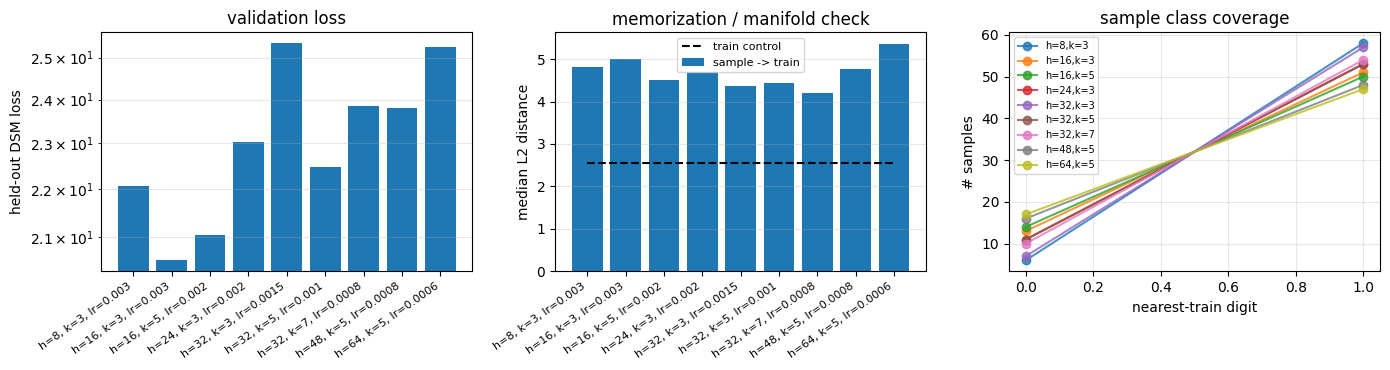

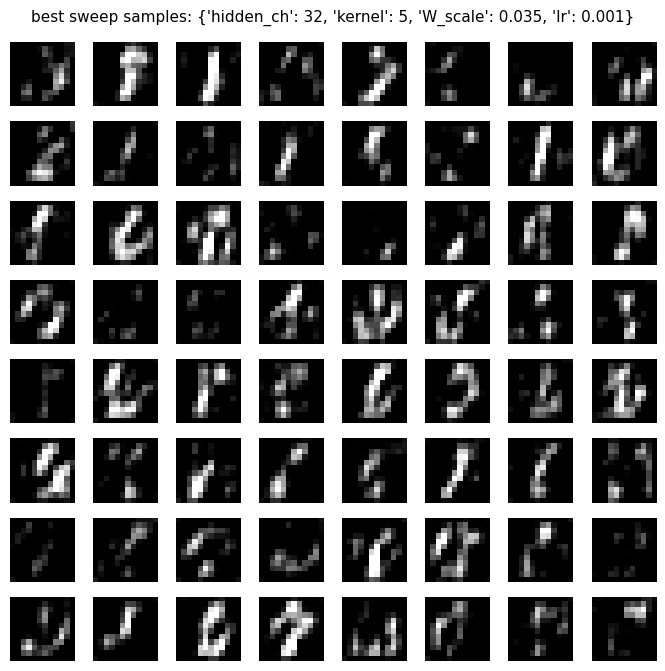

In [13]:
labels = [
    f"h={r['config']['hidden_ch']}, k={r['config']['kernel']}, lr={r['config']['lr']}"
    for r in sweep_results
]
xs = np.arange(len(sweep_results))

fig, axes = plt.subplots(1, 3, figsize=(14.0, 3.8))
axes[0].bar(xs, [r["val_loss"] for r in sweep_results])
axes[0].set_yscale("log")
axes[0].set_ylabel("held-out DSM loss")
axes[0].set_title("validation loss")
axes[0].set_xticks(xs)
axes[0].set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
axes[0].grid(alpha=0.3, axis="y", which="both")

axes[1].bar(xs, [r["median_sample_to_train"] for r in sweep_results], label="sample -> train")
axes[1].plot(xs, [r["median_train_to_train"] for r in sweep_results], "k--", label="train control")
axes[1].set_ylabel("median L2 distance")
axes[1].set_title("memorization / manifold check")
axes[1].set_xticks(xs)
axes[1].set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis="y")

for r in sweep_results:
    counts = [r["digit_counts"][int(d)] for d in DIGITS]
    axes[2].plot(DIGITS, counts, marker="o", alpha=0.8, label=f"h={r['config']['hidden_ch']},k={r['config']['kernel']}")
axes[2].set_xlabel("nearest-train digit")
axes[2].set_ylabel("# samples")
axes[2].set_title("sample class coverage")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

show_image_grid(best["samples"], f"best sweep samples: {best_config}")

## Final quick retrain

The best sweep configuration is retrained with a slightly denser time grid and more steps.
In research mode this is the run to use for figures; in quick mode it is still a smoke-sized
proof of concept.

In [14]:
print("final config:", best_config)
key, sub = random.split(key)
final_params_seq, final_losses, final_wall, key = train_conv_schedule(
    sub,
    train_images,
    best_config,
    TIME_GRID_FINAL,
    steps_per_time=STEPS_PER_TIME_FINAL,
    batch_size=BATCH_SIZE,
    verbose=True,
)
final_stacked = stack_conv_params(final_params_seq)

key, sub = random.split(key)
final_val = validation_dsm_loss(
    final_stacked,
    sub,
    valid_images,
    TIME_GRID_FINAL,
    batch_size=min(128, BATCH_SIZE),
)

key, sub = random.split(key)
final_samples, key = reverse_sample_conv(
    sub,
    final_stacked,
    TIME_GRID_FINAL,
    n_samples=N_SAMPLES,
    n_steps=max(N_REVERSE_STEPS, 100),
)
final_diag = sample_diagnostics(final_samples, train_images, train_labels)
final_summary = summarize_diag(final_diag)

print(f"final wall time: {final_wall:.1f}s")
print(f"final held-out DSM loss: {float(final_val):.4e}")
print("final diagnostics:", final_summary)

final config: {'hidden_ch': 32, 'kernel': 5, 'W_scale': 0.035, 'lr': 0.001}


conv h=32, k=5 | t=3.000 sigma2=0.9975 loss=4.7716e-02


conv h=32, k=5 | t=2.735 sigma2=0.9958 loss=9.0470e-02


conv h=32, k=5 | t=2.469 sigma2=0.9928 loss=1.4085e-01


conv h=32, k=5 | t=2.204 sigma2=0.9878 loss=2.3085e-01


...

conv h=32, k=5 | t=0.876 sigma2=0.8267 loss=3.7181e+00


conv h=32, k=5 | t=0.611 sigma2=0.7053 loss=7.7091e+00


conv h=32, k=5 | t=0.345 sigma2=0.4989 loss=1.7382e+01


conv h=32, k=5 | t=0.080 sigma2=0.1479 loss=1.1894e+02
finished config {'hidden_ch': 32, 'kernel': 5, 'W_scale': 0.035, 'lr': 0.001} in 4.3s


final wall time: 4.3s
final held-out DSM loss: 1.2275e+01
final diagnostics: {'median_sample_to_train': 3.8245105743408203, 'median_train_to_train': 2.5403761863708496, 'digit_counts': {0: 11, 1: 53}}


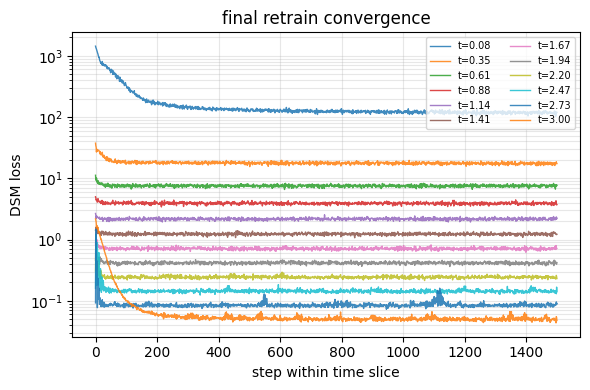

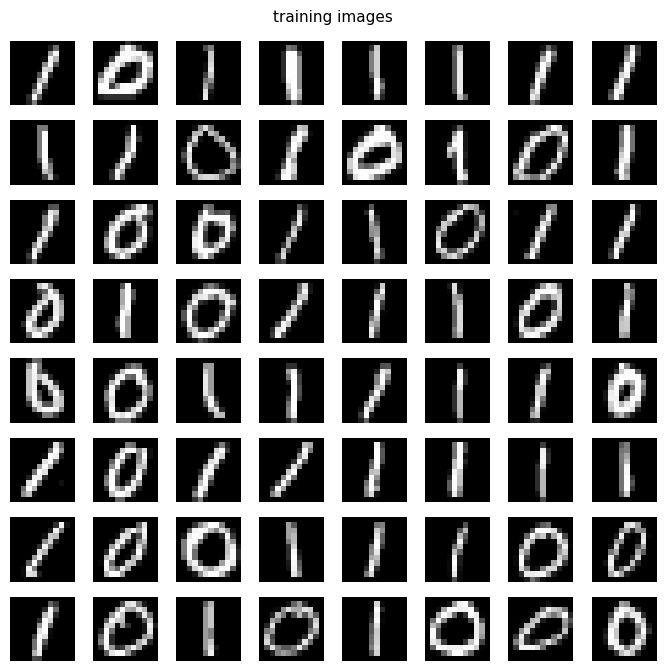

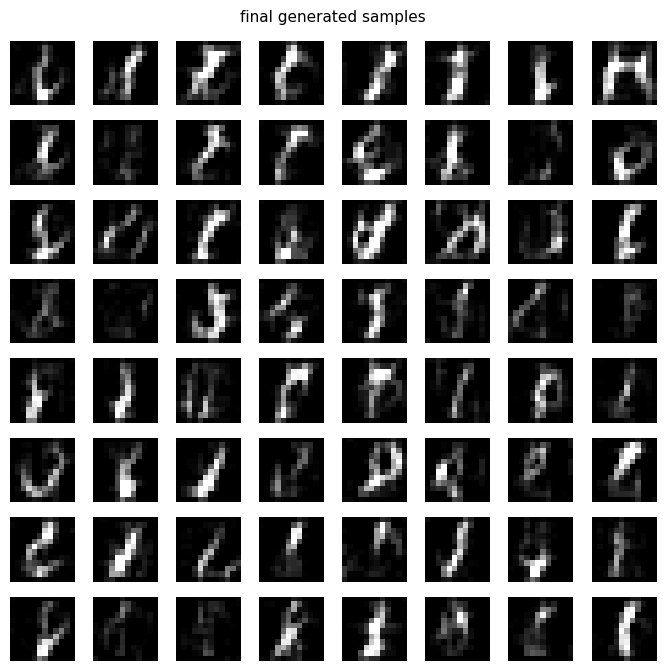

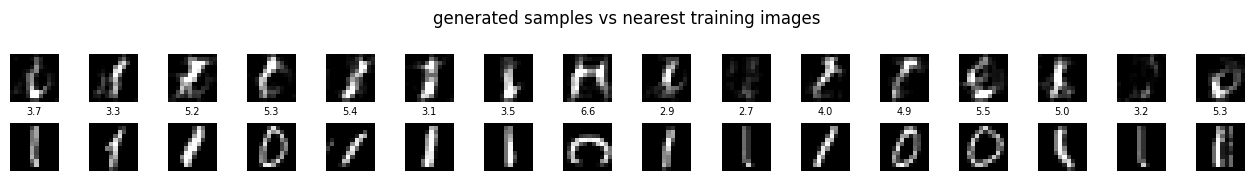

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(6.0, 4.0))
for idx, losses in enumerate(final_losses):
    ax.plot(losses, alpha=0.85, linewidth=1.0, label=f"t={float(TIME_GRID_FINAL[idx]):.2f}")
ax.set_yscale("log")
ax.set_xlabel("step within time slice")
ax.set_ylabel("DSM loss")
ax.set_title("final retrain convergence")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

key, k_view = random.split(key)
idx = random.randint(k_view, (N_SAMPLES,), minval=0, maxval=train_images.shape[0])
show_image_grid(train_images[idx], "training images")
show_image_grid(final_samples, "final generated samples")

# Side-by-side nearest-neighbour visual check.
n_pairs = min(16, N_SAMPLES)
fig, axes = plt.subplots(2, n_pairs, figsize=(0.8 * n_pairs, 1.8))
for i in range(n_pairs):
    axes[0, i].imshow(np.asarray(final_samples[i, :, :, 0]), cmap="gray", vmin=-1, vmax=1)
    axes[0, i].axis("off")
    nn_img = np.asarray(train_images[final_diag["nearest_train_idx"][i], :, :, 0])
    axes[1, i].imshow(nn_img, cmap="gray", vmin=-1, vmax=1)
    axes[1, i].set_title(f"{final_diag['d_sample_train'][i]:.1f}", fontsize=7)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("sample", rotation=0, ha="right", va="center")
axes[1, 0].set_ylabel("nearest", rotation=0, ha="right", va="center")
plt.suptitle("generated samples vs nearest training images")
plt.tight_layout()
plt.show()

## What to inspect

1. **Score/free-energy check.** The max score error should be near float32 precision.
2. **Local-gradient check.** The local crossbar gradient should match autodiff; this is
   the implementation test for the PDF's learning rule.
3. **Validation loss sweep.** Lower held-out DSM loss means a better score field under
   the noising distribution.
4. **Nearest-neighbour distance.** Compare sample-to-train with train-to-train. This is
   a quick memorization/off-manifold diagnostic.
5. **Digit histogram.** A healthy run should not assign all generated samples to one
   nearest-neighbour digit.

The model is intentionally much smaller than a modern diffusion network. The important
claim tested here is narrower: a tied convolutional latent free energy can be trained by
local denoising force matching, on GPU, with MNIST-sized visible states.